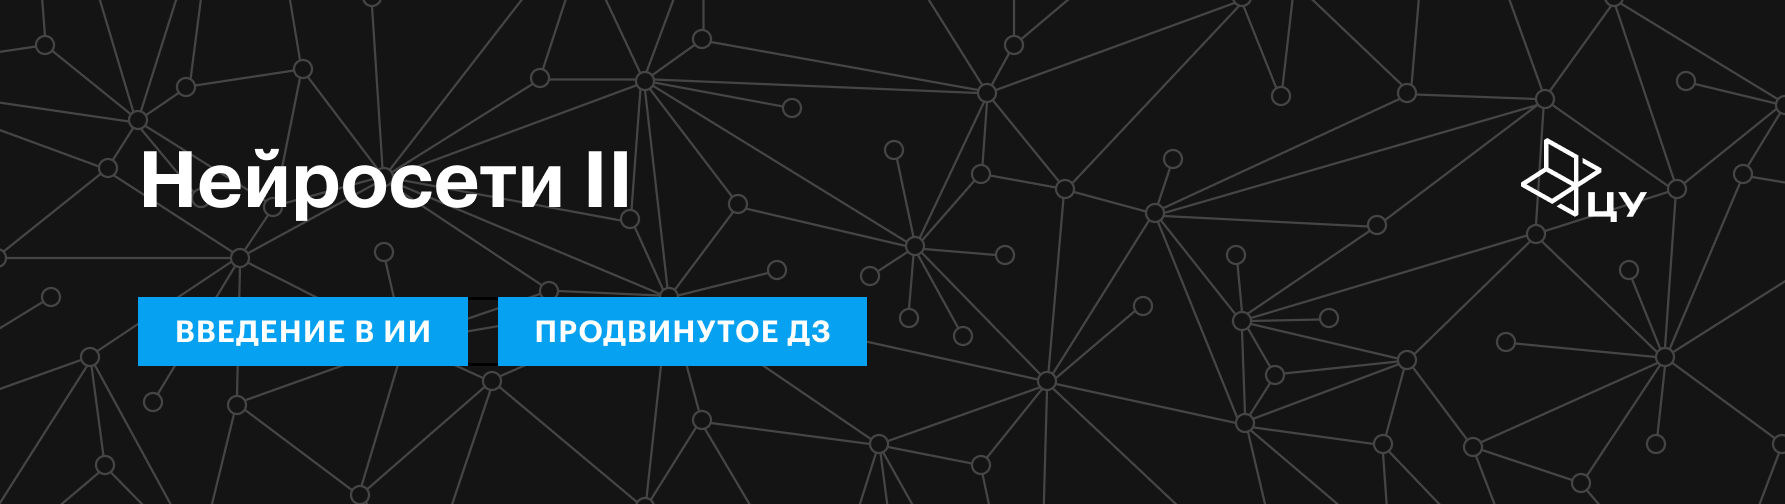

# Домашнее задание по теме «Нейросети II»

Сегодня ты продолжишь работать с самописными слоями нейронных сетей и приведёшь свою функцию потерь к библиотечному варианту.


> ### Правила домашнего задания
>1. Нельзя удалять существующие ячейки кода.
>
>2. Можно добавлять и дописывать свои ячейки.
>
>3. Место, куда тебе нужно написать код, помечается комментарием.
>
>
> 4. Ответ без кода, который подтвердит твоё решение, не засчитывается. Исключение — задачи и вопросы, где код не требуется и нужно сделать вывод из известных данных.
>
 > 5. Код должен быть работоспособным. У проверяющих должна быть возможность воспроизвести все полученные результаты.
>
> 6. Все графики подписывай так, чтобы можно было легко понять их суть. Избегай слишком мелкого или крупного текста, подписывай оси на одном языке.


## Библиотечная и кастомная реализация Cross-Entropy Loss

Во время семинара мы работали с крос-энтропией (Cross-Entropy Loss). Тогда мы сделали выводы, что библиотечная PyTorch-функция реализует более сложную логику по сравнению с версией, написанной вручную.

**Различия библиотечной и кастомной функции потерь**

Стандартная кросс-энтропия в PyTorch автоматически применяет `softmax` и `log` к логитам перед вычислением потерь. В кастомной реализации этого нет, поэтому значения функций потерь могут различаться.

**Почему потери не совпадают**

Различия в значениях потерь возникают из-за того, что в кастомной реализации без `softmax` и `log` теряется числовая стабильность.

**Как добиться совпадения**

Чтобы кастомная реализация совпала с PyTorch, нужно вручную применить `softmax` и `log` к логитам перед расчётом потерь. В `backward` нужно учитывать производные для `softmax`.

В этом задании ты доработаешь решение из семинара, реализовав активацию через `LogSoftmax`.

### LogSoftmax

> [LogSoftmax](https://pytorch.org/docs/stable/generated/torch.nn.LogSoftmax.html) — функция, объединяющая активацию [softmax](https://pytorch.org/docs/stable/generated/torch.nn.Softmax.html) и операцию взятия логарифма.


Чтобы решать задачи многоклассовой классификации, обычно используют `softmax` в качестве нелинейности на последнем слое. Он преобразует логиты в оценки вероятностей классов для каждого объекта:

$$\hat y = softmax(x)  = \bigl \{\frac {exp(x_i)}{\sum_j exp(x_j)} \bigr \}_{i=1}^K, \quad$$
где $K - \text{число классов}$.

В этом случае удобно оптимизировать логарифм правдоподобия:$$L(y, \hat y) = -\sum_{i=1}^K y_i \log \hat y_i \rightarrow \min,$$где $y_i=1$, если объект принадлежит $i$-му классу, и $y_i=0$ в другом случае.

Записанная в таком виде функция потерь совпадает с выражением Cross-Entropy Loss. Чтобы удобнее реализовывать эту функцию, её можно переписать через индексацию, если через $y_i$ обозначить класс данного объекта:$$L(y, \hat y) = - \log \hat y_{i} \rightarrow \min.$$





### LogSumExp

При работе с экспонентами в машинном обучении часто возникает проблема численной нестабильности. Она проявляется в двух случаях:

* **переполнение** (`overflow`) — если значения слишком большие,
`exp(x)` может стать бесконечным (`inf`);
* **потеря точности** (`underflow`) — если значения слишком маленькие, `exp(x)` превращается в ноль и информация теряется.



Чтобы такого не случилось, можно вынести максимум из экспонент вместо вычисления суммы напрямую:

$$ log \Sigma_i e^{(x_i)} = m + log \Sigma_i e^{(x_i-m)}, $$

где $m = max(x_i)$.

Таким образом:

* если все $x_i$ большие — вычитание $m$ предотвращает переполнение;
* если все $x_i$ маленькие — сдвиг помогает отдалиться от нуля, предотвращая потерю точности.

## Задание 1 [5 баллов]

Реализуй слой `LogSoftmax` (без параметров), дополнив код ниже **[5 баллов]**.

**Условия**

 Метод `forward` должен вычислять логарифм от `softmax`, а метод `backward` — пропускать градиенты.

 В общем случае в промежуточных вычислениях `backward` получится трёхмерный тензор, однако для нашей конкретной функции потерь все вычисления можно реализовать в матричном виде.

 Поэтому будем предполагать, что аргумент `grad_output` — это матрица, у которой в каждой строке только одно ненулевое значение (необязательно единица).


>**Подсказка.** Сейчас ты работаешь с большим количеством математических формул и новым функционалом PyTorch, поэтому решение задач может оказаться сложным.

Если возникнут трудности, помогут следующие ресурсы.
* [Документация PyTorch](https://pytorch.org/docs/stable/index.html) — описание функций, классов и примеры использования.
* [Stack Overflow](https://stackoverflow.com/questions) — ответы на вопросы по коду и возникающим ошибкам.




In [64]:
import torch
from torch.autograd import gradcheck

class LogSoftmaxFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, inp):
        # Находим максимум по каждой строке (по классам), сохраняем его для числовой стабильности

        c, arg_m = inp.max(dim=1, keepdim = True)# Напиши код здесь

        # Создаём булевую маску, которая отмечает, какие элементы равны максимуму
        mask = (c == inp)# Напиши код здесь

        # Вычисляем logsumexp: log(sum(exp(inp - c))) для стабилизации softmax
        lse = torch.log(torch.sum(torch.exp(inp - c), dim=1, keepdim=True))# Напиши код здесь

        # Вычисляем log_softmax: inp - c - logsumexp(inp - c)
        output = inp - c - lse# Напиши код здесь

        # Сохраняем нормализованные входные данные и маску для backward
        ctx.save_for_backward(inp - c, mask)

        return output

    @staticmethod
    def backward(ctx, grad_output):
        # Достаём сохранённые тензоры из forward
        norm_inp, mask = ctx.saved_tensors# Напиши код здесь

        batch_size, n_classes = norm_inp.shape

        # Создаём булевую 3D-матрицу для выделения диагонали
        diag_bool = torch.eye(norm_inp.shape[1], norm_inp.shape[1]) \
                        .expand(norm_inp.shape[0], norm_inp.shape[1], norm_inp.shape[1]) > 0


        # Вычисляем сумму экспонент нормализованных входных данных (для нормализации softmax)
        exp_sum = torch.sum(torch.exp(norm_inp), dim=1, keepdim=True)# Напиши код здесь

        # Инициализируем матрицу Якоби, заполненную нулями
        J = torch.zeros((norm_inp.shape[0], norm_inp.shape[1], norm_inp.shape[1]))# Напиши код здесь

        # Заполняем матрицу Якоби значениями производных softmax
        # J[i, j] = -softmax(x_j) для всех элементов
        J = torch.exp(norm_inp) / exp_sum# Напиши код здесь
        J = -J[:, None, :].repeat(1, grad_output.shape[1], 1)

        # Добавляем 1 к диагональным элементам (учёт частной производной d(log_softmax)/dx)
        J[diag_bool] += 1.0

        # Умножаем матрицу Якоби на градиент из следующего слоя
        grad_input = torch.bmm(grad_output.unsqueeze(1), J)

        # Напиши код здесь

        # Убираем лишнюю размерность и возвращаем градиенты
        return grad_input.squeeze(1)# Напиши код здесь

In [65]:
class LogSoftmax(torch.nn.Module):
    def __init__(self):
        super().__init__()
        # Напиши код здесь — посмотри, как это делали на семинаре

    def forward(self, input):
        return LogSoftmaxFunction.apply(input)# Напиши код здесь — посмотри, как это делали на семинаре

Проверяем градиенты.

In [66]:
# Если всё выполнено верно, то в выводе будет только 1 Warning

logsoftmax = LogSoftmaxFunction.apply
x = torch.rand((2,3), requires_grad=True)

assert gradcheck(logsoftmax, x, eps=5e-3)

/usr/local/lib/python3.12/dist-packages/torch/autograd/gradcheck.py:2106: UserWarning: Input #0 requires gradient and is not a double precision floating point or complex. This check will likely fail if all the inputs are not of double precision floating point or complex. 
  _check_inputs(tupled_inputs)


In [67]:
# Если всё выполнено верно, то вывод будет пустой

our_softmax = LogSoftmax()
torch_softmax = torch.nn.LogSoftmax(dim=1)

assert torch.norm(our_softmax(x.float()) - torch_softmax(x)) < 1e-5

## Задание 2 [3 балла]

Отлично! Теперь нужно заново собрать весь пайплайн решения (используй функции из семинара), заменив в архитектуре выходную активацию `sigmoid` на `LogSoftmax`.

Обучи самописную модель и модель на PyTorch так, чтобы значения `Accuracy` у них были сопоставимы **[3 балла]**.


In [68]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torch.nn.functional as F
import torch.nn as nn

In [69]:
class IdkWhy(nn.Module):
  def forward(self, x):
    return LogSoftmaxFunction.apply(x)


In [70]:
class PyTorchModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(PyTorchModel, self).__init__()
        self.linear1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.linear2 = nn.Linear(hidden_dim, output_dim)
        self.logsoftmax = nn.LogSoftmax(dim=1)

    def forward(self, x):
        x = self.linear1(x)
        x = self.relu(x)
        x = self.linear2(x)
        x = self.logsoftmax(x)
        return x

class CustomModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(CustomModel, self).__init__()
        self.linear1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.linear2 = nn.Linear(hidden_dim, output_dim)
        self.LogSoftmaxFunction = IdkWhy()

    def forward(self, x):
        x = self.linear1(x)
        x = self.relu(x)
        x = self.linear2(x)
        x = self.LogSoftmaxFunction(x)
        return x

# Напиши код здесь
# Если всё корректно, то должны выйти сопоставимые значения метрики Accuracy
# Отличный результат — 0,8 для самописной модели и 0,82 для PyTorch-модели

In [71]:
# Загрузка данных Fashion MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1))  # Преобразуем изображения в одномерные векторы
])

train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


In [72]:
torch.manual_seed(42)


In [73]:
def train(model, criterion, optimizer, data_loader, epochs=5):
    for epoch in range(epochs):
        total_loss = 0
        for data, target in data_loader:
            optimizer.zero_grad()  # Обнуляем градиенты
            output = model(data)   # Прямой проход
            loss = criterion(output, target)  # Вычисляем потерю
            loss.backward()  # Обратный проход
            optimizer.step()  # Обновляем параметры
            total_loss += loss.item()

        print(f"Epoch [{epoch+1}/{epochs}], Loss: {total_loss/len(data_loader)}")

In [98]:
# Создаём модели
input_dim = 784  # 28 * 28
hidden_dim = 128
output_dim = 10  # 10 классов в Fashion MNIST

custom_model = CustomModel(input_dim, hidden_dim, output_dim)
pytorch_model = PyTorchModel(input_dim, hidden_dim, output_dim)

# Оптимизаторы для обеих моделей
optimizer_custom = torch.optim.SGD(custom_model.parameters(), lr=0.01)
optimizer_pytorch = torch.optim.SGD(pytorch_model.parameters(), lr=0.01)

# Функция потерь для обеих моделей
# criterion = CrossEntropyCustom()

# Обучение обеих моделей
train(custom_model, nn.NLLLoss(), optimizer_custom, train_loader, epochs=5)
train(pytorch_model, nn.NLLLoss(), optimizer_pytorch, train_loader, epochs=5)

# Проверка на тестовых данных
def test(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data, target in test_loader:
            output = model(data)
            predicted = torch.argmax(output, dim=1)
            correct += (predicted == target).sum().item()
            total += target.size(0)

    print(f"Accuracy: {100 * correct / total}%")

# Проверяем точность обеих моделей
test(custom_model, test_loader)
test(pytorch_model, test_loader)


Epoch [1/5], Loss: 1.1415554614209418
Epoch [2/5], Loss: 0.673551746173454
Epoch [3/5], Loss: 0.5773822664261372
Epoch [4/5], Loss: 0.5301769206137545
Epoch [5/5], Loss: 0.5012263544777563
Epoch [1/5], Loss: 1.1408026196809211
Epoch [2/5], Loss: 0.6715334548052948
Epoch [3/5], Loss: 0.5780384562798401
Epoch [4/5], Loss: 0.5314399360148891
Epoch [5/5], Loss: 0.5024853891401149
Accuracy: 82.38%
Accuracy: 81.84%


## Задание 3 [2 балла]

Ты уже знаешь разные функции активации, например: `ReLU`, `Sigmoid` и `softmax`. Однако их существует гораздо больше.

Это творческое задание, направленное на расширение кругозора. Выбери любую функцию активации, изучи её и реализуй кастомную версию **[1 балл]**.

1. **Сравни выходные значения** **[0,25 балла].**

   Подай одинаковый вход (`input`) в обе функции и сравни `output`. Если они разные, возможно, ошибка в реализации.

2. **Проверь градиенты (gradcheck)** **[0,25 балла].**

   Используй `torch.autograd.gradcheck()`, который проверяет правильность градиентов методом численного дифференцирования.

3. **Визуализируй выходы и градиенты** **[0,25 балла].**

   Построй графики: `input` → `output` (зависимость выходных данных от входных данных) и `input` → `gradient` (зависимость производной от входных данных) для библиотечной и самописной функций.

4. **Проверь производительность (скорость выполнения)** **[0,25 балла].**

   Засеки время выполнения `.forward()` и `.backward()`.
   Самописная функция, скорее всего, будет медленнее из-за неэффективной реализации.

In [91]:
class LeakyRelu(torch.autograd.Function):
  @staticmethod
  def forward(ctx, inp):
    mask = inp < 0
    output = inp.clone()
    output[mask] *= 0.01

    ctx.save_for_backward(mask)

    return output

  @staticmethod
  def backward(ctx, grad_output):

    mask = ctx.saved_tensors
    grad_input = grad_output.clone()
    grad_input[mask] *= 0.01

    return grad_input

def custom_leaky_relu(x):
    return LeakyRelu.apply(x)

def torch_leaky_relu(x):
    return F.leaky_relu(x, negative_slope=0.01)

In [92]:
x = torch.linspace(-5, 5, steps=20)

y_custom = custom_leaky_relu(x)
y_torch = torch_leaky_relu(x)

print("Custom output:\n", y_custom)
print("Torch output:\n", y_torch)
print("Max abs diff:", torch.max(torch.abs(y_custom - y_torch)).item())
print("All close:", torch.allclose(y_custom, y_torch, atol=1e-6))

Custom output:
 tensor([-5.0000e-02, -4.4737e-02, -3.9474e-02, -3.4211e-02, -2.8947e-02,
        -2.3684e-02, -1.8421e-02, -1.3158e-02, -7.8947e-03, -2.6316e-03,
         2.6316e-01,  7.8947e-01,  1.3158e+00,  1.8421e+00,  2.3684e+00,
         2.8947e+00,  3.4211e+00,  3.9474e+00,  4.4737e+00,  5.0000e+00])
Torch output:
 tensor([-5.0000e-02, -4.4737e-02, -3.9474e-02, -3.4211e-02, -2.8947e-02,
        -2.3684e-02, -1.8421e-02, -1.3158e-02, -7.8947e-03, -2.6316e-03,
         2.6316e-01,  7.8947e-01,  1.3158e+00,  1.8421e+00,  2.3684e+00,
         2.8947e+00,  3.4211e+00,  3.9474e+00,  4.4737e+00,  5.0000e+00])
Max abs diff: 0.0
All close: True


In [93]:
x = torch.randn(10, dtype=torch.double, requires_grad=True)

test = torch.autograd.gradcheck(LeakyRelu.apply, (x,), eps=1e-6, atol=1e-4)

print("Gradcheck:", test)

Gradcheck: True


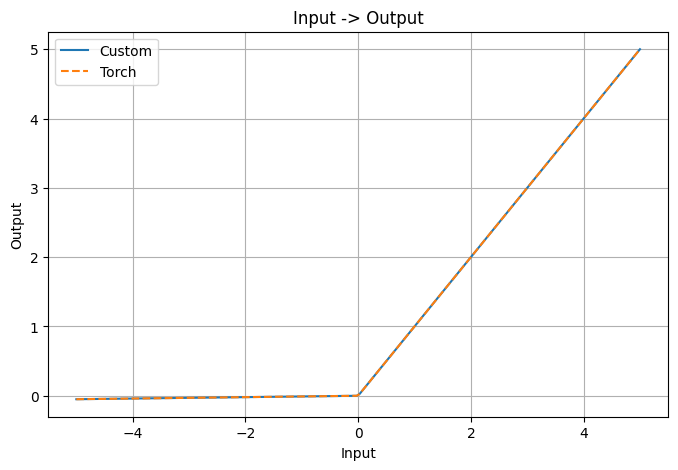

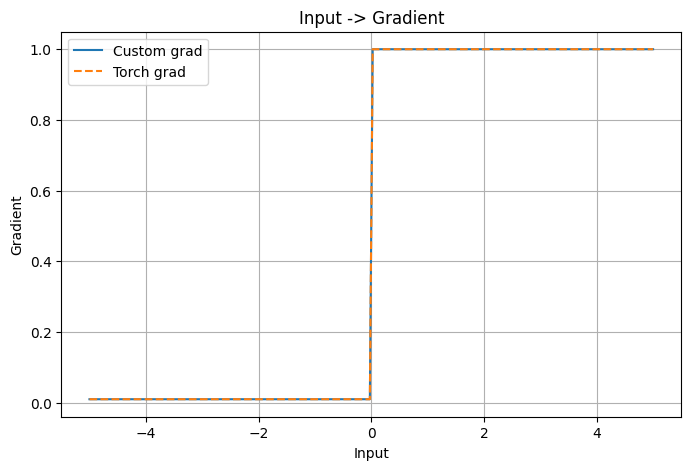

In [96]:
x_custom = torch.linspace(-5, 5, steps=200, requires_grad=True)
x_torch = x_custom.clone().detach().requires_grad_(True)

y_custom = custom_leaky_relu(x_custom)
y_torch = torch_leaky_relu(x_torch)

y_custom.sum().backward()
y_torch.sum().backward()

plt.figure(figsize=(8, 5))
plt.plot(x_custom.detach().numpy(), y_custom.detach().numpy(), label='Custom')
plt.plot(x_torch.detach().numpy(), y_torch.detach().numpy(), '--', label='Torch')
plt.title('Input -> Output')
plt.xlabel('Input')
plt.ylabel('Output')
plt.grid(True)
plt.legend()

plt.figure(figsize=(8, 5))
plt.plot(x_custom.detach().numpy(), x_custom.grad.detach().numpy(), label='Custom grad')
plt.plot(x_torch.detach().numpy(), x_torch.grad.detach().numpy(), '--', label='Torch grad')
plt.title('Input -> Gradient')
plt.xlabel('Input')
plt.ylabel('Gradient')
plt.grid(True)
plt.legend()

In [97]:
import time
import torch
import torch.nn.functional as F

x1 = torch.randn(1_000_000, requires_grad=True)
x2 = x1.clone().detach().requires_grad_(True)

start = time.time()
y1 = custom_leaky_relu(x1)
custom_forward_time = time.time() - start

start = time.time()
y1.sum().backward()
custom_backward_time = time.time() - start

start = time.time()
y2 = torch_leaky_relu(x2)
torch_forward_time = time.time() - start

start = time.time()
y2.sum().backward()
torch_backward_time = time.time() - start

print(f"Custom forward time:  {custom_forward_time:.6f} sec")
print(f"Custom backward time: {custom_backward_time:.6f} sec")
print(f"Torch forward time:   {torch_forward_time:.6f} sec")
print(f"Torch backward time:  {torch_backward_time:.6f} sec")

Custom forward time:  0.030447 sec
Custom backward time: 0.030751 sec
Torch forward time:   0.001487 sec
Torch backward time:  0.005420 sec
